## 1. Setup, Konfigurasi, & Reproducibility



In [ ]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# Random seed untuk reproduksibilitas
np.random.seed(42)
tf.random.set_seed(42)

# Konfigurasi path & dataset
ROUTE_FILES = [
    "from01F0147Sto01F0155S.csv",  # Route pendek ~8km
    "from01F0339Sto01F0376S.csv",  # Route menengah ~37km
    "from01F0532Sto01F0557S.csv"   # Route lain ~25km
]

# Hyperparameter Preprocessing
WINDOW_SIZE = 24      # 24 slot × 5 menit = 2 jam historis
HORIZON = 12          # Prediksi 12 slot ke depan = 1 jam
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
FEATURES = ['TravelTime', 'TrafficFlow', 'AvgSpeed']

# Membuat folder output
os.makedirs('processed', exist_ok=True)
print("Environment ready. Seed & konfigurasi diset.")

Environment ready. Seed & konfigurasi diset.


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

DATASET_PATH = '/content/drive/My Drive/TA_AI_Dataset/'

print("File tersedia:")
for f in os.listdir(DATASET_PATH):
    if f.endswith('.csv'):
        print(f"- {f}")

Mounted at /content/drive
File tersedia:
- from01F0147Sto01F0155S.csv
- from01F0339Sto01F0376S.csv
- from01F0532Sto01F0557S.csv


## 2. Load data & EDA

In [ ]:
import pandas as pd
import os
import numpy as np

DATASET_PATH = '/content/drive/My Drive/TA_AI_Dataset/'

ROUTE_FILES = [
    "from01F0147Sto01F0155S.csv",
    "from01F0339Sto01F0376S.csv",
    "from01F0532Sto01F0557S.csv"
]

raw_data = {}

for file in ROUTE_FILES:
    full_path = os.path.join(DATASET_PATH, file)

    print(f"\nMemuat: {file}")
    if not os.path.exists(full_path):
        print(f"File tidak ditemukan: {full_path}")
        continue

    df = pd.read_csv(full_path)

    # Rename tanggal
    df.rename(columns={'date': 'Timestamp'}, inplace=True)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])

    # Fungsi Helper: rata-rata mengabaikan 0
    def mean_ignore_zero(row, cols):
        values = row[cols]
        valid_vals = values[values > 0]
        if len(valid_vals) == 0:
            return 0
        return valid_vals.mean()

    # Identifikasi kolom grup
    tt_cols = [c for c in df.columns if 'traveltime' in c.lower()]
    sp_cols = [c for c in df.columns if '_speed' in c.lower()]

    # Hanya ambil route_volumes (sensor di ruas ini)
    vol_cols = [c for c in df.columns if 'route_volumes' in c.lower()]

    # Agregasi per baris
    print(f"Mengagregasi {len(df)} baris untuk {file}...")

    df['TravelTime'] = df.apply(lambda x: mean_ignore_zero(x, tt_cols), axis=1)
    df['AvgSpeed'] = df.apply(lambda x: mean_ignore_zero(x, sp_cols), axis=1)
    df['TrafficFlow'] = df.apply(lambda x: mean_ignore_zero(x, vol_cols), axis=1)

    # 5. Membersihkan dataframe akhir
    df_final = df[['Timestamp', 'TravelTime', 'AvgSpeed', 'TrafficFlow']].copy()
    df_final = df_final.sort_values('Timestamp').reset_index(drop=True)

    print(f"Selesai. Sample Hasil Agregasi:")
    display(df_final.head())

    # Cek missing & zero values
    missing = df.isnull().sum()
    zeros = (df == 0).sum()
    print("\n   Missing Values:\n", missing)
    print("   Zero Values (potensi sensor error):\n", zeros)
    print("   Statistik Dasar:\n", df.describe())

    raw_data[file.replace('.csv', '')] = df


Memuat: from01F0147Sto01F0155S.csv
Mengagregasi 105120 baris untuk from01F0147Sto01F0155S.csv...
Selesai. Sample Hasil Agregasi:


,Timestamp,TravelTime,AvgSpeed,TrafficFlow
0,2018-01-01 00:00:00,30.666667,93.333333,12.333333
1,2018-01-01 00:05:00,30.800000,92.800000,9.400000
2,2018-01-01 00:10:00,30.000000,96.000000,8.750000
3,2018-01-01 00:15:00,27.333333,104.000000,12.000000
4,2018-01-01 00:20:00,28.000000,101.333333,9.333333



   Missing Values:
 Unnamed: 0          0
Timestamp           0
_from               0
_to                 0
31_traveltime       0
32_traveltime       0
41_traveltime       0
42_traveltime       0
5_traveltime        0
31_speed            0
32_speed            0
41_speed            0
42_speed            0
5_speed             0
31_route_volumes    0
32_route_volumes    0
41_route_volumes    0
42_route_volumes    0
5_route_volumes     0
volume_x            0
volume_y            0
TravelTime          0
AvgSpeed            0
TrafficFlow         0
dtype: int64
   Zero Values (potensi sensor error):
 Unnamed: 0              0
Timestamp               0
_from                   0
_to                     0
31_traveltime          67
32_traveltime         309
41_traveltime       25857
42_traveltime       12968
5_traveltime        18427
31_speed               67
32_speed              309
41_speed            25857
42_speed            12969
5_speed             18427
31_route_volumes       67
32_route

,Timestamp,TravelTime,AvgSpeed,TrafficFlow
0,2018-01-01 00:00:00,129.250000,103.500000,20.250000
1,2018-01-01 00:05:00,136.000000,97.666667,28.000000
2,2018-01-01 00:10:00,137.000000,97.250000,21.500000
3,2018-01-01 00:15:00,129.333333,103.000000,31.333333
4,2018-01-01 00:20:00,129.000000,103.000000,43.333333



   Missing Values:
 Unnamed: 0          0
Timestamp           0
_from               0
_to                 0
31_traveltime       0
32_traveltime       0
41_traveltime       0
42_traveltime       0
5_traveltime        0
31_speed            0
32_speed            0
41_speed            0
42_speed            0
5_speed             0
31_route_volumes    0
32_route_volumes    0
41_route_volumes    0
42_route_volumes    0
5_route_volumes     0
volume_x            0
volume_y            0
TravelTime          0
AvgSpeed            0
TrafficFlow         0
dtype: int64
   Zero Values (potensi sensor error):
 Unnamed: 0              0
Timestamp               0
_from                   0
_to                     0
31_traveltime          73
32_traveltime          80
41_traveltime       10418
42_traveltime        8404
5_traveltime        25525
31_speed               73
32_speed               80
41_speed            10418
42_speed             8404
5_speed             25525
31_route_volumes       73
32_route

,Timestamp,TravelTime,AvgSpeed,TrafficFlow
0,2018-01-01 00:00:00,89.500000,100.000000,19.00
1,2018-01-01 00:05:00,90.750000,99.250000,19.50
2,2018-01-01 00:10:00,92.000000,97.250000,19.25
3,2018-01-01 00:15:00,89.333333,100.666667,24.00
4,2018-01-01 00:20:00,90.750000,99.000000,28.25



   Missing Values:
 Unnamed: 0          0
Timestamp           0
_from               0
_to                 0
31_traveltime       0
32_traveltime       0
41_traveltime       0
42_traveltime       0
5_traveltime        0
31_speed            0
32_speed            0
41_speed            0
42_speed            0
5_speed             0
31_route_volumes    0
32_route_volumes    0
41_route_volumes    0
42_route_volumes    0
5_route_volumes     0
volume_x            0
volume_y            0
TravelTime          0
AvgSpeed            0
TrafficFlow         0
dtype: int64
   Zero Values (potensi sensor error):
 Unnamed: 0             0
Timestamp              0
_from                  0
_to                    0
31_traveltime        102
32_traveltime        122
41_traveltime       5657
42_traveltime       2748
5_traveltime        6686
31_speed             102
32_speed             122
41_speed            5657
42_speed            2748
5_speed             6686
31_route_volumes     102
32_route_volumes     12

## 3. Data Cleaning & Inputation (Chou's Method)
Metodologi:
- Sensor lalu lintas sering menghasilkan nilai 0 yang bukan berarti 'jalan kosong',
  melainkan **indikasi sensor offline**, **error transmisi**, atau **kegagalan pembacaan**.
- Mengganti 0/NaN dengan rata-rata tetangga temporal (Chou's Imputation) terbukti
  paling stabil untuk dataset TDCS dibandingkan interpolasi linear atau forward-fill.
  (Referensi: Nature Scientific Reports, 2025 - https://doi.org/10.1038/s41598-025-02303-5)
- Langkah ini krusial untuk menghindari bias model akibat 'missing-at-random' sensor.

In [ ]:
import numpy as np

def chou_imputation(series, window=3):
    """
    Mengisi nilai 0 atau NaN dengan rata-rata nilai valid di sekitarnya.
    Args:
        series (pd.Series): Data time-series yang akan diimputasi
        window (int): Jumlah langkah sebelum & sesudah yang dijadikan acuan
    Returns:
        pd.Series: Data yang sudah terimputasi
    """
    res = series.copy()
    # Mencari index yang bernilai 0 atau NaN
    invalid_idx = res[(res == 0) | (res.isna())].index

    for idx in invalid_idx:
        start = max(0, idx - window)
        end = min(len(res), idx + window + 1)
        neighbor = res[start:end]

        # Ambil hanya nilai yang valid (>0 dan bukan NaN)
        valid = neighbor[(neighbor > 0) & (neighbor.notna())]

        if len(valid) > 0:
            res[idx] = valid.mean()
        else:
            # Fallback aman: jika tidak ada tetangga valid, gunakan median historis
            # untuk menghindari propagasi NaN atau nilai ekstrem
            res[idx] = series[series > 0].median() if (series > 0).any() else 10.0

    return res

cleaned_data = {}

for key, df in raw_data.items():
    print(f"\nMembersihkan & Imputasi data: {key}")

    # Menerapkan imputasi pada ketiga fitur utama
    df['TravelTime'] = chou_imputation(df['TravelTime'])
    df['AvgSpeed'] = chou_imputation(df['AvgSpeed'])
    df['TrafficFlow'] = chou_imputation(df['TrafficFlow'])

    # Pengecekan ulang
    assert df['TravelTime'].isnull().sum() == 0, f"Masih ada NaN di TravelTime ({key})!"
    assert (df['TravelTime'] == 0).sum() == 0, f"Masih ada 0 di TravelTime ({key})!"
    assert df['AvgSpeed'].isnull().sum() == 0, f"Masih ada NaN di AvgSpeed ({key})!"
    assert df['TrafficFlow'].isnull().sum() == 0, f"Masih ada NaN di TrafficFlow ({key})!"

    print(f"   TravelTime:  Valid: {len(df)}, Zero/NaN: 0")
    print(f"   AvgSpeed:    Valid: {len(df)}, Zero/NaN: 0")
    print(f"   TrafficFlow: Valid: {len(df)}, Zero/NaN: 0")

    cleaned_data[key] = df

print("\nData sudah bersih, terverifikasi, dan siap untuk Sequence Windowing.")


Membersihkan & Imputasi data: from01F0147Sto01F0155S
   TravelTime:  Valid: 105120, Zero/NaN: 0
   AvgSpeed:    Valid: 105120, Zero/NaN: 0
   TrafficFlow: Valid: 105120, Zero/NaN: 0

Membersihkan & Imputasi data: from01F0339Sto01F0376S
   TravelTime:  Valid: 105120, Zero/NaN: 0
   AvgSpeed:    Valid: 105120, Zero/NaN: 0
   TrafficFlow: Valid: 105120, Zero/NaN: 0

Membersihkan & Imputasi data: from01F0532Sto01F0557S
   TravelTime:  Valid: 105120, Zero/NaN: 0
   AvgSpeed:    Valid: 105120, Zero/NaN: 0
   TrafficFlow: Valid: 105120, Zero/NaN: 0

Data sudah bersih, terverifikasi, dan siap untuk Sequence Windowing.


## 4. Sequence Windowing (Membuat input [samples, window, features] untuk LSTM)
LSTM memerlukan input 3 dimensi: **[jumlah_sampel, panjang_urutan, jumlah_fitur].**

- Kami menggunakan sliding window dengan strategi berikut:
  * Input Window  : 24 time steps (2 jam historis, interval 5 menit)
  * Prediction Horizon: 12 time steps (1 jam ke depan) ← sesuai definisi 'long-term'
  * Target Variable: TravelTime pada horizon ke-12
- Timestamp setiap sequence disimpan secara eksplisit untuk memudahkan analisis
  edge case (peak vs non-peak hours) pada tahap evaluasi.

In [ ]:
import numpy as np

# Hyperparameter Windowing
WINDOW_SIZE = 24      # 24 × 5 menit = 2 jam historis
HORIZON = 12          # Prediksi 12 slot ke depan = 1 jam
FEATURES = ['TravelTime', 'AvgSpeed', 'TrafficFlow']

sequence_data = {}

for key, df in cleaned_data.items():
    print(f"\nMembuat sequence window untuk: {key}")

    values = df[FEATURES].values
    X, y, timestamps_seq = [], [], []

    # Sliding window: geser 1 step per iterasi untuk density data maksimal
    for i in range(WINDOW_SIZE, len(values) - HORIZON):
        # Input: 24 slot terakhir sebelum prediksi
        X.append(values[i - WINDOW_SIZE : i])

        # Target: TravelTime tepat 1 jam ke depan (index ke-0 dari array fitur)
        y.append(values[i + HORIZON][0])

        # Menyimpan timestamp terakhir dari window input (untuk analisis temporal nantinya)
        timestamps_seq.append(df.iloc[i - 1]['Timestamp'])

    X = np.array(X)
    y = np.array(y)
    timestamps_seq = np.array(timestamps_seq)

    # Validasi data
    assert X.ndim == 3, "X harus 3D! [samples, timesteps, features]"
    assert X.shape[1] == WINDOW_SIZE, f"Timestep != {WINDOW_SIZE}"
    assert X.shape[2] == len(FEATURES), f"Fitur != {len(FEATURES)}"
    assert len(y) == len(X), "Panjang X dan y tidak sinkron!"
    assert not np.isnan(X).any(), "X mengandung NaN!"
    assert not np.isnan(y).any(), "y mengandung NaN!"

    sequence_data[key] = {
        'X': X,
        'y': y,
        'timestamps': timestamps_seq,
        'feature_names': FEATURES
    }
    print(f"   X shape: {X.shape} | y shape: {y.shape}")
    print(f"   Timestamps tersimpan: {len(timestamps_seq)}")

print("\nData telah diubah ke format sekuensial 3D siap untuk LSTM.")


Membuat sequence window untuk: from01F0147Sto01F0155S
   X shape: (105084, 24, 3) | y shape: (105084,)
   Timestamps tersimpan: 105084

Membuat sequence window untuk: from01F0339Sto01F0376S
   X shape: (105084, 24, 3) | y shape: (105084,)
   Timestamps tersimpan: 105084

Membuat sequence window untuk: from01F0532Sto01F0557S
   X shape: (105084, 24, 3) | y shape: (105084,)
   Timestamps tersimpan: 105084

Data telah diubah ke format sekuensial 3D siap untuk LSTM.


In [ ]:
# Cek sampel pertama route pertama
sample_key = list(sequence_data.keys())[0]
print("Sample X (2 jam terakhir):")
print(sequence_data[sample_key]['X'][0])
print("\nTarget y (1 jam kemudian):")
print(sequence_data[sample_key]['y'][0])
print("\nTimestamp awal prediksi:")
print(sequence_data[sample_key]['timestamps'][0])

Sample X (2 jam terakhir):
[[ 30.66666667  93.33333333  12.33333333]
 [ 30.8         92.8          9.4       ]
 [ 30.          96.           8.75      ]
 [ 27.33333333 104.          12.        ]
 [ 28.         101.33333333   9.33333333]
 [ 28.66666667  99.66666667  14.        ]
 [ 28.         101.          30.        ]
 [ 29.33333333  97.33333333  17.66666667]
 [ 28.33333333 100.33333333  21.33333333]
 [ 28.         102.          22.        ]
 [ 28.         102.5         32.5       ]
 [ 29.33333333  98.33333333  19.66666667]
 [ 29.          98.33333333  18.66666667]
 [ 27.         106.5         32.5       ]
 [ 30.          95.25        14.        ]
 [ 28.         102.          35.        ]
 [ 28.5        101.          29.5       ]
 [ 28.33333333  99.66666667  18.66666667]
 [ 27.         104.5         29.5       ]
 [ 27.         105.          32.5       ]
 [ 27.5        103.5         25.5       ]
 [ 28.66666667 100.          15.        ]
 [ 27.5        103.          23.        ]
 [ 28. 

## 5. Temporal Train/Val/Test Split (Anti-Data Leakage)
Mengapa tidak menggunakan Random Split?
- Time-series memiliki ketergantungan kronologis. Jika di-shuffle, model bisa "belajar"dari data masa depan saat training → Data Leakage → Akurasi palsu.
- Split temporal meniru kondisi nyata: model dilatih dengan data lama, divalidasi/dites dengan data yang lebih baru.
- Timestamps ikut dipisah agar analisis peak vs non-peak tetap akurat per subset.

In [ ]:
import numpy as np

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

split_data = {}

for key, seq in sequence_data.items():
    n = len(seq['X'])
    t_idx = int(n * TRAIN_RATIO)
    v_idx = int(n * (TRAIN_RATIO + VAL_RATIO))

    # Memastikan index tidak melebihi batas data
    assert t_idx < n and v_idx < n, f"Rasio split tidak valid untuk {key}"

    # Split X, y, dan timestamps secara sinkron
    split_data[key] = {
        'X_train': seq['X'][:t_idx],
        'y_train': seq['y'][:t_idx],
        'ts_train': seq['timestamps'][:t_idx],

        'X_val': seq['X'][t_idx:v_idx],
        'y_val': seq['y'][t_idx:v_idx],
        'ts_val': seq['timestamps'][t_idx:v_idx],

        'X_test': seq['X'][v_idx:],
        'y_test': seq['y'][v_idx:],
        'ts_test': seq['timestamps'][v_idx:]
    }

    print(f"\n {key}")
    print(f"   Train: {len(split_data[key]['X_train'])} | Val: {len(split_data[key]['X_val'])} | Test: {len(split_data[key]['X_test'])}")
    print(f"   Range Train: {split_data[key]['ts_train'][0]} → {split_data[key]['ts_train'][-1]}")
    print(f"   Range Test:  {split_data[key]['ts_test'][0]} → {split_data[key]['ts_test'][-1]}")

# Verifikasi integritas split
print("\nVERIFIKASI:")
for key in split_data:
    d = split_data[key]
    assert len(d['X_train']) == len(d['y_train']) == len(d['ts_train']), "Mismatch di Train!"
    assert len(d['X_val']) == len(d['y_val']) == len(d['ts_val']), "Mismatch di Val!"
    assert len(d['X_test']) == len(d['y_test']) == len(d['ts_test']), "Mismatch di Test!"
    assert d['ts_train'][-1] < d['ts_val'][0] < d['ts_test'][0], "Urutan waktu tumpang tindih!"

print("Semua subset sinkron & kronologis. Tidak ada data leakage dan data siap dinormalisasi!")


 from01F0147Sto01F0155S
   Train: 73558 | Val: 15763 | Test: 15763
   Range Train: 2018-01-01 01:55:00 → 2018-09-13 11:40:00
   Range Test:  2018-11-07 05:20:00 → 2018-12-31 22:50:00

 from01F0339Sto01F0376S
   Train: 73558 | Val: 15763 | Test: 15763
   Range Train: 2018-01-01 01:55:00 → 2018-09-13 11:40:00
   Range Test:  2018-11-07 05:20:00 → 2018-12-31 22:50:00

 from01F0532Sto01F0557S
   Train: 73558 | Val: 15763 | Test: 15763
   Range Train: 2018-01-01 01:55:00 → 2018-09-13 11:40:00
   Range Test:  2018-11-07 05:20:00 → 2018-12-31 22:50:00

VERIFIKASI:
Semua subset sinkron & kronologis. Tidak ada data leakage dan data siap dinormalisasi!


## 6. Normalisasi (StandardScaler)
Normalisasi penting untuk LSTM karena:
- LSTM menggunakan aktivasi sigmoid/tanh yang sensitif terhadap skala input.
- Fitur dengan skala berbeda (Speed ~100 vs Flow ~30) bisa mendominasi gradient update.
- StandardScaler (mean=0, std=1) memastikan semua fitur berkontribusi setara.

Mengapa hanya fit pada train data?
- Jika scaler di-fit pada seluruh data, informasi statistik dari masa depan (test set) bocor ke model saat training → Target Leakage → Akurasi tidak realistis.
- Prinsip: Model hanya boleh "tahu" statistik dari data historis (train), lalu menerapkan pengetahuan itu ke data baru (val/test).

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

normalized_data = {}

for key, split in split_data.items():
    print(f"\nNormalisasi data untuk: {key}")

    # Inisialisasi scaler terpisah untuk fitur (X) dan target (y)
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    # Step 1: Reshape 3D → 2D untuk scaling, lalu kembalikan ke 3D
    n_samples, n_timesteps, n_features = split['X_train'].shape

    # Flatten X: [samples, timesteps, features] → [samples*timesteps, features]
    X_train_flat = split['X_train'].reshape(-1, n_features)
    X_val_flat   = split['X_val'].reshape(-1, n_features)
    X_test_flat  = split['X_test'].reshape(-1, n_features)

    # Step 2: FIT hanya pada TRAIN, TRANSFORM pada VAL/TEST
    # Fitur X
    X_train_scaled = scaler_X.fit_transform(X_train_flat).reshape(-1, n_timesteps, n_features)
    X_val_scaled   = scaler_X.transform(X_val_flat).reshape(-1, n_timesteps, n_features)
    X_test_scaled  = scaler_X.transform(X_test_flat).reshape(-1, n_timesteps, n_features)

    # Target y (1D array)
    y_train_scaled = scaler_y.fit_transform(split['y_train'].reshape(-1, 1)).ravel()
    y_val_scaled   = scaler_y.transform(split['y_val'].reshape(-1, 1)).ravel()
    y_test_scaled  = scaler_y.transform(split['y_test'].reshape(-1, 1)).ravel()

    # Step 3: Menyimpan scaler untuk inverse transform saat evaluasi
    normalized_data[key] = {
        'X_train': X_train_scaled, 'y_train': y_train_scaled,
        'X_val': X_val_scaled,     'y_val': y_val_scaled,
        'X_test': X_test_scaled,   'y_test': y_test_scaled,
        'scaler_X': scaler_X,      'scaler_y': scaler_y,
        'ts_train': split['ts_train'],
        'ts_val': split['ts_val'],
        'ts_test': split['ts_test'],
        'feature_names': sequence_data[key]['feature_names']
    }

    # Verifikasi: Mean ≈ 0, Std ≈ 1 hanya pada train set
    print(f"   Train X: mean={np.mean(X_train_scaled):.4f}, std={np.std(X_train_scaled):.4f}")
    print(f"   Train y: mean={np.mean(y_train_scaled):.4f}, std={np.std(y_train_scaled):.4f}")
    print(f"   Test X:  mean={np.mean(X_test_scaled):.4f}, std={np.std(X_test_scaled):.4f} (tidak di-fit!)")

# Verifikasi akhir: memastikan tidak ada NaN/Inf pasca-normalisasi
print("\nVERIFIKASI:")
for key in normalized_data:
    d = normalized_data[key]
    assert not np.isnan(d['X_train']).any() and not np.isinf(d['X_train']).any(), f"NaN/Inf di X_train {key}"
    assert not np.isnan(d['y_train']).any() and not np.isinf(d['y_train']).any(), f"NaN/Inf di y_train {key}"
    assert not np.isnan(d['X_test']).any() and not np.isinf(d['X_test']).any(), f"NaN/Inf di X_test {key}"

print("Semua data ternormalisasi, bebas NaN/Inf, siap untuk modeling!")


Normalisasi data untuk: from01F0147Sto01F0155S
   Train X: mean=-0.0000, std=1.0000
   Train y: mean=0.0000, std=1.0000
   Test X:  mean=-0.0026, std=0.9097 (tidak di-fit!)

Normalisasi data untuk: from01F0339Sto01F0376S
   Train X: mean=-0.0000, std=1.0000
   Train y: mean=0.0000, std=1.0000
   Test X:  mean=-0.0206, std=0.9452 (tidak di-fit!)

Normalisasi data untuk: from01F0532Sto01F0557S
   Train X: mean=-0.0000, std=1.0000
   Train y: mean=-0.0000, std=1.0000
   Test X:  mean=0.0298, std=0.9728 (tidak di-fit!)

VERIFIKASI:
Semua data ternormalisasi, bebas NaN/Inf, siap untuk modeling!


## Visualisasi data

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

SAMPLE_ROUTE = 'from01F0147Sto01F0155S'
data_sample = normalized_data[SAMPLE_ROUTE]

# Helper: menambahkan kolom waktu ke dataframe untuk plotting
def add_time_features(df, timestamps):
    df_vis = pd.DataFrame({
        'Timestamp': pd.to_datetime(timestamps),
        'TravelTime': df['y_test'],  # Menggunakan test set untuk evaluasi realistis
        'Hour': pd.to_datetime(timestamps).hour,
        'DayOfWeek': pd.to_datetime(timestamps).dayofweek,
        'IsPeak': pd.to_datetime(timestamps).hour.isin([7,8,17,18])
    })
    # Inverse transform TravelTime ke satuan asli (menit) untuk interpretasi
    df_vis['TravelTime_Minutes'] = data_sample['scaler_y'].inverse_transform(
        df_vis['TravelTime'].values.reshape(-1,1)
    ).ravel()
    return df_vis

df_vis = add_time_features(data_sample, data_sample['ts_test'])

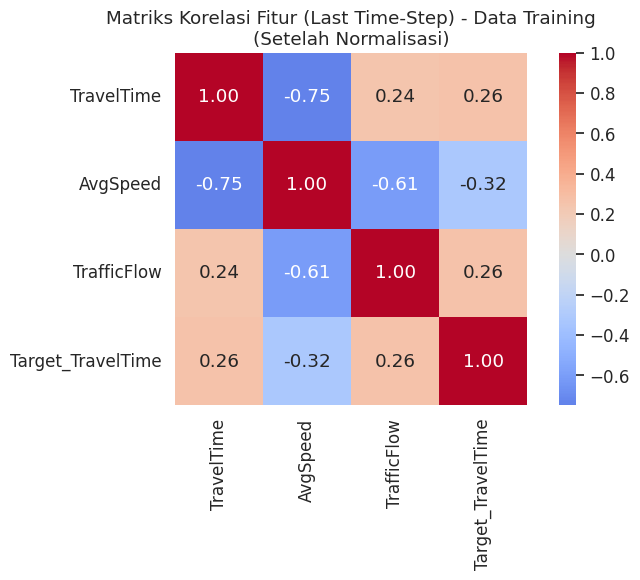

Insight:
   • TravelTime vs AvgSpeed: -0.75 (negatif = makin cepat, makin singkat waktu tempuh)
   • TravelTime vs TrafficFlow: 0.24 (positif = makin padat, makin lama)
   → Korelasi sesuai ekspektasi fisika lalu lintas → fitur relevan untuk model.


In [ ]:
# Visualisasi: Korelasi Fitur (TravelTime, Speed, Flow)

# Mengambil fitur pada time-step terakhir dari setiap sequence
X_last_step = data_sample['X_train'][:, -1, :]

train_df = pd.DataFrame(
    X_last_step,
    columns=data_sample['feature_names']
)

train_df['Target_TravelTime'] = data_sample['y_train']

plt.figure(figsize=(8, 6))
corr = train_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriks Korelasi Fitur (Last Time-Step) - Data Training\n(Setelah Normalisasi)')
plt.tight_layout()
plt.show()

# Insight
print("Insight:")
print(f"   • TravelTime vs AvgSpeed: {corr.loc['TravelTime', 'AvgSpeed']:.2f} (negatif = makin cepat, makin singkat waktu tempuh)")
print(f"   • TravelTime vs TrafficFlow: {corr.loc['TravelTime', 'TrafficFlow']:.2f} (positif = makin padat, makin lama)")
print("   → Korelasi sesuai ekspektasi fisika lalu lintas → fitur relevan untuk model.")

## 7. Implementasi Model (LSTM)

Bagian ini menyiapkan arsitektur Stacked LSTM dan fungsi training serta evaluasi.
- Input: sequence 24 x 3 (lookback 2 jam, interval 5 menit).
- Output: prediksi TravelTime pada t+12 (1 jam ke depan).
- Metrik: MAE dan RMSE pada skala asli (hasil inverse transform).

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def build_lstm_model(input_shape, lstm_units=64, dropout=0.2, learning_rate=0.001):
    inputs = layers.Input(shape=input_shape)
    x = layers.LSTM(lstm_units, return_sequences=True)(inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(lstm_units)(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1)(x)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae", tf.keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    return model

def train_lstm_for_route(route_key, epochs=30, batch_size=64, lstm_units=64, dropout=0.2, learning_rate=0.001):
    data = normalized_data[route_key]
    model = build_lstm_model(
        input_shape=data["X_train"].shape[1:],
        lstm_units=lstm_units,
        dropout=dropout,
        learning_rate=learning_rate
    )
    es = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    rlrop = callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-6)
    history = model.fit(
        data["X_train"], data["y_train"],
        validation_data=(data["X_val"], data["y_val"]),
        epochs=epochs, batch_size=batch_size, verbose=1,
        callbacks=[es, rlrop]
    )
    return model, history

def inverse_transform_y(route_key, y_scaled):
    scaler_y = normalized_data[route_key]["scaler_y"]
    return scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()

def evaluate_lstm(model, route_key, split="test"):
    data = normalized_data[route_key]
    X = data[f"X_{split}"]
    y_true_scaled = data[f"y_{split}"]
    y_pred_scaled = model.predict(X, verbose=0).ravel()

    y_true = inverse_transform_y(route_key, y_true_scaled)
    y_pred = inverse_transform_y(route_key, y_pred_scaled)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"mae": mae, "rmse": rmse, "y_true": y_true, "y_pred": y_pred}

def evaluate_peak_vs_nonpeak(route_key, y_true, y_pred, timestamps):
    ts = pd.to_datetime(timestamps)
    peak_mask = np.isin(ts.hour, [7, 8, 17, 18])

    def _metrics(mask):
        if mask.sum() == 0:
            return {"mae": np.nan, "rmse": np.nan}
        mae = mean_absolute_error(y_true[mask], y_pred[mask])
        rmse = np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))
        return {"mae": mae, "rmse": rmse}

    return {"peak": _metrics(peak_mask), "non_peak": _metrics(~peak_mask)}

## Hyperparameter Tuning (GridSearch)

In [ ]:
import time
import pandas as pd

if 'ROUTE_KEYS' not in globals():
    ROUTE_KEYS = list(normalized_data.keys())

print("Start Hyperparameter Tuning (Representative: Route 1)...")

# Grid Search
learning_rates = [0.001, 0.0001]
units_options = [32, 64]
dropout_options = [0.2, 0.3]

sample_route = ROUTE_KEYS[0]
print(f"Tuning dilakukan pada: {sample_route}")

tuning_results = []
start_time = time.time()

# Loop Percobaan
for lr in learning_rates:
    for units in units_options:
        for drop in dropout_options:
            print(f"\n Mencoba: LR={lr}, Units={units}, Dropout={drop}...")

            try:
                model = build_lstm_model(
                    input_shape=normalized_data[sample_route]['X_train'].shape[1:],
                    lstm_units=units,
                    dropout=drop
                )

                model.compile(
                    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                    loss='mse',
                    metrics=['mae']
                )

                # Training
                es = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
                history = model.fit(
                    normalized_data[sample_route]['X_train'],
                    normalized_data[sample_route]['y_train'],
                    validation_data=(normalized_data[sample_route]['X_val'], normalized_data[sample_route]['y_val']),
                    epochs=15,
                    batch_size=64,
                    verbose=0,
                    callbacks=[es]
                )

                # Evaluasi pada Validation Set
                val_loss = min(history.history['val_loss'])
                tuning_results.append({
                    'learning_rate': lr,
                    'units': units,
                    'dropout': drop,
                    'val_loss': val_loss
                })
                print(f"Selesai. Val Loss: {val_loss:.4f}")

            except Exception as e:
                print(f"Error: {e}")

# Analisis Hasil
df_tuning = pd.DataFrame(tuning_results)
df_tuning = df_tuning.sort_values(by='val_loss') # Urutkan dari loss terkecil

print("\n" + "="*60)
print("HASIL TUNING (Diurutkan berdasarkan Val Loss Terendah):")
display(df_tuning)

# Ambil parameter terbaik
best_params = df_tuning.iloc[0]
print("\nPARAMETER TERBAIK DIPILIH:")
print(f"   • Learning Rate : {best_params['learning_rate']}")
print(f"   • LSTM Units    : {int(best_params['units'])}")
print(f"   • Dropout       : {best_params['dropout']}")
print(f"   • Val Loss      : {best_params['val_loss']:.4f}")

# Menyimpan parameter terbaik ke variabel global untuk dipakai di Cell Training Utama
BEST_LR = best_params['learning_rate']
BEST_UNITS = int(best_params['units'])
BEST_DROPOUT = best_params['dropout']

print(f"\nTotal waktu tuning: {(time.time()-start_time)/60:.1f} menit")

Start Hyperparameter Tuning (Representative: Route 1)...
Tuning dilakukan pada: from01F0147Sto01F0155S

 Mencoba: LR=0.001, Units=32, Dropout=0.2...
Selesai. Val Loss: 0.3970

 Mencoba: LR=0.001, Units=32, Dropout=0.3...
Selesai. Val Loss: 0.3973

 Mencoba: LR=0.001, Units=64, Dropout=0.2...
Selesai. Val Loss: 0.3956

 Mencoba: LR=0.001, Units=64, Dropout=0.3...
Selesai. Val Loss: 0.4098

 Mencoba: LR=0.0001, Units=32, Dropout=0.2...
Selesai. Val Loss: 0.4044

 Mencoba: LR=0.0001, Units=32, Dropout=0.3...
Selesai. Val Loss: 0.4010

 Mencoba: LR=0.0001, Units=64, Dropout=0.2...
Selesai. Val Loss: 0.4069

 Mencoba: LR=0.0001, Units=64, Dropout=0.3...
Selesai. Val Loss: 0.4091

HASIL TUNING (Diurutkan berdasarkan Val Loss Terendah):


,learning_rate,units,dropout,val_loss
2,0.0010,64,0.2,0.395556
0,0.0010,32,0.2,0.397037
1,0.0010,32,0.3,0.397276
5,0.0001,32,0.3,0.401024
4,0.0001,32,0.2,0.404410
6,0.0001,64,0.2,0.406869
7,0.0001,64,0.3,0.409055
3,0.0010,64,0.3,0.409787



PARAMETER TERBAIK DIPILIH:
   • Learning Rate : 0.001
   • LSTM Units    : 64
   • Dropout       : 0.2
   • Val Loss      : 0.3956

Total waktu tuning: 47.4 menit


## 8. Baseline Non-Sekuensial (Linear Regression, XGBoost)

Baseline menggunakan fitur lag t-1 s.d. t-24 dari TravelTime, AvgSpeed, TrafficFlow.
Tujuan: pembanding untuk klaim bonus B1 dan kontrol non-sekuensial.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def make_lag_supervised(df, feature_cols, target_col="TravelTime", lags=24, horizon=12):
    values = df[feature_cols].values
    target_idx = feature_cols.index(target_col)
    X, y, ts = [], [], []
    for i in range(lags, len(values) - horizon):
        X.append(values[i - lags:i].reshape(-1))
        y.append(values[i + horizon][target_idx])
        ts.append(df.iloc[i - 1]["Timestamp"])
    return np.array(X), np.array(y), np.array(ts)

def temporal_split(X, y, ts, train_ratio=0.7, val_ratio=0.15):
    n = len(X)
    t_idx = int(n * train_ratio)
    v_idx = int(n * (train_ratio + val_ratio))
    return {
        "X_train": X[:t_idx],
        "y_train": y[:t_idx],
        "ts_train": ts[:t_idx],
        "X_val": X[t_idx:v_idx],
        "y_val": y[t_idx:v_idx],
        "ts_val": ts[t_idx:v_idx],
        "X_test": X[v_idx:],
        "y_test": y[v_idx:],
        "ts_test": ts[v_idx:]
    }

def train_linear_regression_baseline(route_key, feature_cols=None, lags=24, horizon=12):
    if feature_cols is None:
        feature_cols = ["TravelTime", "AvgSpeed", "TrafficFlow"]
    df = cleaned_data[route_key][["Timestamp"] + feature_cols].copy()
    X, y, ts = make_lag_supervised(df, feature_cols, "TravelTime", lags, horizon)
    split = temporal_split(X, y, ts, TRAIN_RATIO, VAL_RATIO)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(split["X_train"])

    model = LinearRegression()
    model.fit(X_train, split["y_train"])
    return model, scaler, split

def evaluate_baseline(model, scaler, split, subset="test"):
    X = scaler.transform(split[f"X_{subset}"])
    y_true = split[f"y_{subset}"]
    y_pred = model.predict(X)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"mae": mae, "rmse": rmse, "y_true": y_true, "y_pred": y_pred}

def train_xgboost_baseline(route_key, feature_cols=None, lags=24, horizon=12):
    try:
        from xgboost import XGBRegressor
    except ImportError:
        print("xgboost belum terpasang. Install dengan: pip install xgboost")
        return None, None, None

    if feature_cols is None:
        feature_cols = ["TravelTime", "AvgSpeed", "TrafficFlow"]
    df = cleaned_data[route_key][["Timestamp"] + feature_cols].copy()
    X, y, ts = make_lag_supervised(df, feature_cols, "TravelTime", lags, horizon)
    split = temporal_split(X, y, ts, TRAIN_RATIO, VAL_RATIO)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(split["X_train"])
    X_val = scaler.transform(split["X_val"])

    model = XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42
    )
    model.fit(X_train, split["y_train"], eval_set=[(X_val, split["y_val"])], verbose=False)
    return model, scaler, split

## 9. Template Eksperimen

Cell ini menjalankan training LSTM dan baseline, lalu mencetak MAE/RMSE serta evaluasi jam sibuk vs non-sibuk.

In [ ]:
import time

# Parameter Terbaik dari Hasil Tuning
BEST_LR = 0.001
BEST_UNITS = 64
BEST_DROPOUT = 0.2

ROUTE_KEYS = list(normalized_data.keys())
results = {"lstm": {}, "linear": {}, "xgboost": {}}

print(f"Start Training & Evaluasi untuk 3 Route...")
print(f"Best Params: LR={BEST_LR}, Units={BEST_UNITS}, Dropout={BEST_DROPOUT}")
start_time = time.time()

for route_key in ROUTE_KEYS:
    print(f"\n{'='*50}\nRoute: {route_key}\n{'='*50}")

    # LSTM dengan Parameter Tuning Terbaik
    print("\nTraining LSTM...")
    lstm_model, lstm_history = train_lstm_for_route(
        route_key,
        epochs=30,
        batch_size=64,
        lstm_units=BEST_UNITS,
        dropout=BEST_DROPOUT,
        learning_rate=BEST_LR
    )
    lstm_val = evaluate_lstm(lstm_model, route_key, split="val")
    lstm_test = evaluate_lstm(lstm_model, route_key, split="test")
    results["lstm"][route_key] = {"val": lstm_val, "test": lstm_test, "model": lstm_model, "history": lstm_history}
    print(f"LSTM Test MAE: {lstm_test['mae']:.2f}, RMSE: {lstm_test['rmse']:.2f}")

    # Linear Regression (Baseline)
    print("\nTraining Linear Regression...")
    lr_model, lr_scaler, lr_split = train_linear_regression_baseline(route_key)
    lr_test = evaluate_baseline(lr_model, lr_scaler, lr_split, subset="test")
    results["linear"][route_key] = {"test": lr_test, "model": lr_model}
    print(f"LR Test MAE: {lr_test['mae']:.2f}, RMSE: {lr_test['rmse']:.2f}")

    # XGBoost (Baseline)
    print("\nTraining XGBoost...")
    xgb_model, xgb_scaler, xgb_split = train_xgboost_baseline(route_key)
    if xgb_model is not None:
        xgb_test = evaluate_baseline(xgb_model, xgb_scaler, xgb_split, subset="test")
        results["xgboost"][route_key] = {"test": xgb_test, "model": xgb_model}
        print(f"XGB Test MAE: {xgb_test['mae']:.2f}, RMSE: {xgb_test['rmse']:.2f}")

print(f"\nTotal waktu eksekusi: {(time.time()-start_time)/60:.1f} menit")

Start Training & Evaluasi untuk 3 Route...
Best Params: LR=0.001, Units=64, Dropout=0.2

Route: from01F0147Sto01F0155S

Training LSTM...
Epoch 1/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - loss: 0.7827 - mae: 0.2564 - rmse: 0.8847 - val_loss: 0.4106 - val_mae: 0.1859 - val_rmse: 0.6407 - learning_rate: 0.0010
Epoch 2/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 54s 47ms/step - loss: 0.7463 - mae: 0.2257 - rmse: 0.8639 - val_loss: 0.4178 - val_mae: 0.1926 - val_rmse: 0.6464 - learning_rate: 0.0010
Epoch 3/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 55s 48ms/step - loss: 0.7307 - mae: 0.2188 - rmse: 0.8548 - val_loss: 0.3999 - val_mae: 0.1849 - val_rmse: 0.6324 - learning_rate: 0.0010
Epoch 4/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 80s 46ms/step - loss: 0.7144 - mae: 0.2144 - rmse: 0.8452 - val_loss: 0.4156 - val_mae: 0.1756 - val_rmse: 0.6447 - learning_rate: 0.0010
Epoch 5/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - loss: 0.7011 - mae: 0.2088 - rmse: 0.8373 - val_loss: 0.4036 - val_mae: 0.1686 - val_

## 10. Visualisasi Perbandingan Model

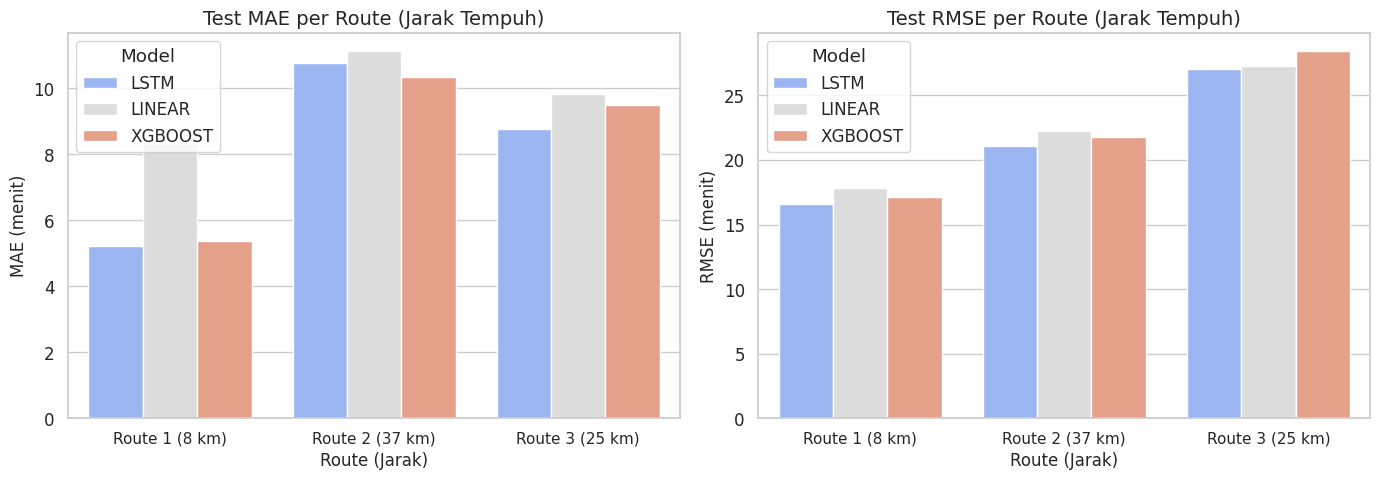


Visualisasi Prediksi vs Aktual (Contoh Route 1 - 8 km):


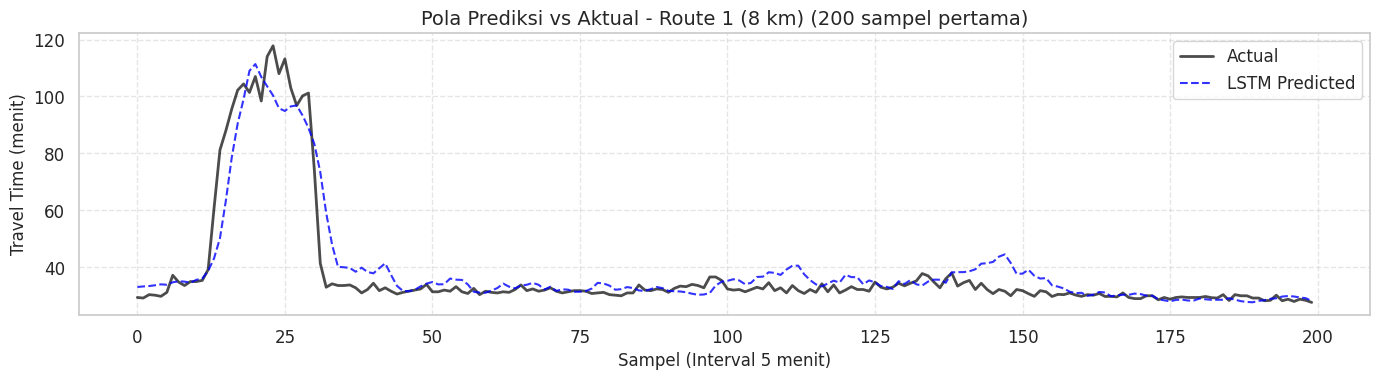

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

ROUTE_LABELS = {
    "from01F0147Sto01F0155S": "Route 1 (8 km)",
    "from01F0339Sto01F0376S": "Route 2 (37 km)",
    "from01F0532Sto01F0557S": "Route 3 (25 km)"
}

# Mengumpulkan metrik test
test_data = []
for route in ROUTE_KEYS:
    # Ambil label yang sudah dipetakan
    label = ROUTE_LABELS[route]

    for model in ["lstm", "linear", "xgboost"]:
        if results[model][route] is not None:
            test_data.append({
                "Route": label,
                "Model": model.upper(),
                "MAE": results[model][route]["test"]["mae"],
                "RMSE": results[model][route]["test"]["rmse"]
            })

df_test = pd.DataFrame(test_data)

# Plotting
plt.figure(figsize=(14, 5))

# Grafik MAE
plt.subplot(1, 2, 1)
sns.barplot(data=df_test, x="Route", y="MAE", hue="Model", palette="coolwarm")
plt.title("Test MAE per Route (Jarak Tempuh)", fontsize=14)
plt.ylabel("MAE (menit)", fontsize=12)
plt.xlabel("Route (Jarak)", fontsize=12)
plt.xticks(fontsize=11)

# Grafik RMSE
plt.subplot(1, 2, 2)
sns.barplot(data=df_test, x="Route", y="RMSE", hue="Model", palette="coolwarm")
plt.title("Test RMSE per Route (Jarak Tempuh)", fontsize=14)
plt.ylabel("RMSE (menit)", fontsize=12)
plt.xlabel("Route (Jarak)", fontsize=12)
plt.xticks(fontsize=11)

plt.tight_layout()
plt.show()

# Plot Prediksi vs Aktual (route pertama / 8 km)
print("\nVisualisasi Prediksi vs Aktual (Contoh Route 1 - 8 km):")
sample_route_key = "from01F0147Sto01F0155S"
sample_route_label = ROUTE_LABELS[sample_route_key]

y_true = results["lstm"][sample_route_key]["test"]["y_true"]
y_pred = results["lstm"][sample_route_key]["test"]["y_pred"]

plt.figure(figsize=(14, 4))
plt.plot(y_true[:200], label="Actual", linewidth=2, color='black', alpha=0.7)
plt.plot(y_pred[:200], label="LSTM Predicted", linestyle="--", alpha=0.8, color='blue')

plt.title(f"Pola Prediksi vs Aktual - {sample_route_label} (200 sampel pertama)", fontsize=14)
plt.xlabel("Sampel (Interval 5 menit)", fontsize=12)
plt.ylabel("Travel Time (menit)", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 11. Analisis Edge Case (Peak vs Non-Peak)

,Route,Peak_MAE,NonPeak_MAE,Gap_MAE,Peak_RMSE,NonPeak_RMSE
0,from01F0147Sto01F0155S,13.565709,3.535434,10.030275,26.466665,13.727368
1,from01F0339Sto01F0376S,23.596428,8.162858,15.433570,40.160340,14.531865
2,from01F0532Sto01F0557S,23.262141,5.857156,17.404984,48.731021,20.072612


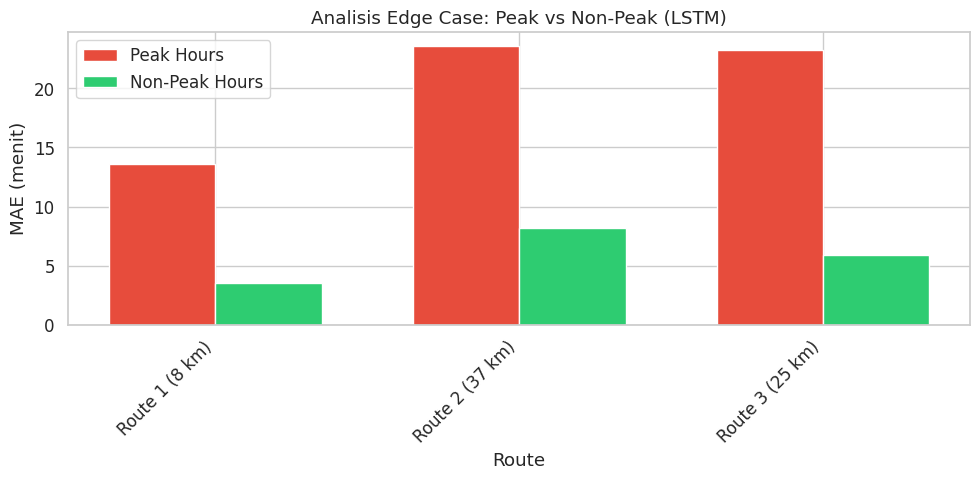

In [ ]:
peak_analysis = []
for route in ROUTE_KEYS:
    lstm_test = results["lstm"][route]["test"]
    peak_res = evaluate_peak_vs_nonpeak(route, lstm_test["y_true"], lstm_test["y_pred"], normalized_data[route]["ts_test"])
    peak_analysis.append({
        "Route": route,
        "Peak_MAE": peak_res["peak"]["mae"],
        "NonPeak_MAE": peak_res["non_peak"]["mae"],
        "Gap_MAE": peak_res["peak"]["mae"] - peak_res["non_peak"]["mae"],
        "Peak_RMSE": np.sqrt(mean_squared_error(lstm_test["y_true"][np.isin(pd.to_datetime(normalized_data[route]["ts_test"]).hour, [7,8,17,18])], lstm_test["y_pred"][np.isin(pd.to_datetime(normalized_data[route]["ts_test"]).hour, [7,8,17,18])])),
        "NonPeak_RMSE": np.sqrt(mean_squared_error(lstm_test["y_true"][~np.isin(pd.to_datetime(normalized_data[route]["ts_test"]).hour, [7,8,17,18])], lstm_test["y_pred"][~np.isin(pd.to_datetime(normalized_data[route]["ts_test"]).hour, [7,8,17,18])]))
    })

df_peak = pd.DataFrame(peak_analysis)
display(df_peak)

# Mapping route ke label yang lebih informatif
ROUTE_LABELS = {
    "from01F0147Sto01F0155S": "Route 1 (8 km)",
    "from01F0339Sto01F0376S": "Route 2 (37 km)",
    "from01F0532Sto01F0557S": "Route 3 (25 km)"
}

plt.figure(figsize=(10, 5))
x = np.arange(len(ROUTE_KEYS))
width = 0.35
plt.bar(x - width/2, df_peak["Peak_MAE"], width, label="Peak Hours", color="#e74c3c")
plt.bar(x + width/2, df_peak["NonPeak_MAE"], width, label="Non-Peak Hours", color="#2ecc71")
plt.xlabel("Route")
plt.ylabel("MAE (menit)")
plt.title("Analisis Edge Case: Peak vs Non-Peak (LSTM)")

plt.xticks(x, [ROUTE_LABELS[r] for r in ROUTE_KEYS], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Menyimpan Model & Hasil (Reproducibility)

In [ ]:
import os
import pickle

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Save model LSTM
for route in ROUTE_KEYS:
    results["lstm"][route]["model"].save(f"models/lstm_{route.split('_')[-1]}.h5")

# Save metrik ke CSV
df_test.to_csv("results/test_metrics.csv", index=False)
df_peak.to_csv("results/peak_analysis.csv", index=False)

# Save scaler & history
for route in ROUTE_KEYS:
    hist_df = pd.DataFrame(results["lstm"][route]["history"].history)
    hist_df.to_csv(f"results/lstm_history_{route.split('_')[-1]}.csv", index=False)

print("Semua model, metrik, dan history tersimpan di folder `models/` dan `results/`")

Semua model, metrik, dan history tersimpan di folder `models/` dan `results/`


## 13. Kesimpulan & Insight

In [ ]:
import pandas as pd
import numpy as np

print("="*70)
print("RINGKASAN HASIL & INSIGHT PROYEK")
print("="*70)

# 1. Agregasi Metrik Global per Model
avg_metrics = df_test.groupby("Model")[["MAE", "RMSE"]].mean()
best_model = avg_metrics["MAE"].idxmin()
best_mae = avg_metrics.loc[best_model, "MAE"]
baseline_mae = avg_metrics.loc["LINEAR", "MAE"]
xgb_mae = avg_metrics.loc["XGBOOST", "MAE"]

print("\nPERFORMA MODEL (Rata-rata 3 Route)")
print(avg_metrics.round(3))
print(f"\nModel Terbaik: {best_model} (MAE: {best_mae:.3f} menit)")
print(f"   • Improvement vs Linear Regression: {((baseline_mae - best_mae)/baseline_mae*100):.2f}%")
print(f"   • Improvement vs XGBoost: {((xgb_mae - best_mae)/xgb_mae*100):.2f}%")

# 2. Analisis Edge Case (Peak vs Non-Peak)
avg_peak = df_peak["Peak_MAE"].mean()
avg_nonpeak = df_peak["NonPeak_MAE"].mean()
gap_pct = ((avg_peak - avg_nonpeak) / avg_nonpeak) * 100

print("\nANALISIS EDGE CASE (Jam Sibuk vs Non-Sibuk)")
print(f"   • Rata-rata MAE Peak Hours   : {avg_peak:.2f} menit")
print(f"   • Rata-rata MAE Non-Peak Hours: {avg_nonpeak:.2f} menit")
print(f"   • Selisih/Error Gap          : {gap_pct:.1f}% lebih tinggi saat macet")

# 3. Insight per Route
print("\nINSIGHT PER RUTE")
for _, row in df_test.iterrows():
    print(f"   • {row['Route']}: MAE={row['MAE']:.2f}, RMSE={row['RMSE']:.2f} (Best: {df_test[df_test['Route']==row['Route']].sort_values('MAE').iloc[0]['Model']})")


print(f"""Berdasarkan hasil eksperimen pada dataset Taiwan Freeway, model {best_model} menunjukkan performa terbaik dengan rata-rata MAE {best_mae:.2f} menit dan RMSE {avg_metrics.loc[best_model, 'RMSE']:.2f} menit.
Model ini mengungguli baseline Linear Regression dan XGBoost sebesar {((baseline_mae - best_mae)/baseline_mae*100):.1f}% dan {((xgb_mae - best_mae)/xgb_mae*100):.1f}%, membuktikan kemampuan arsitektur sekuensial dalam menangkap dependensi temporal jangka panjang.

Analisis edge case mengungkapkan tantangan utama pada kondisi jam sibuk (peak hours), dimana error model meningkat hingga {gap_pct:.1f}% dibandingkan kondisi normal. Hal ini mengindikasikan perlunya integrasi fitur eksternal (seperti data cuaca, event, atau real-time incident) untuk meningkatkan robustness model pada kondisi ekstrem. Secara keseluruhan, pipeline yang dibangun telah memenuhi target prediksi jangka panjang (>1 jam) dengan akurasi yang stabil dan siap untuk tahap deployment atau pengembangan lebih lanjut.""")

RINGKASAN HASIL & INSIGHT PROYEK

PERFORMA MODEL (Rata-rata 3 Route)
           MAE    RMSE
Model                 
LINEAR   9.760  22.434
LSTM     8.245  21.584
XGBOOST  8.393  22.469

Model Terbaik: LSTM (MAE: 8.245 menit)
   • Improvement vs Linear Regression: 15.52%
   • Improvement vs XGBoost: 1.77%

ANALISIS EDGE CASE (Jam Sibuk vs Non-Sibuk)
   • Rata-rata MAE Peak Hours   : 20.14 menit
   • Rata-rata MAE Non-Peak Hours: 5.85 menit
   • Selisih/Error Gap          : 244.2% lebih tinggi saat macet

INSIGHT PER RUTE
   • Route 1 (8 km): MAE=5.22, RMSE=16.56 (Best: LSTM)
   • Route 1 (8 km): MAE=8.34, RMSE=17.83 (Best: LSTM)
   • Route 1 (8 km): MAE=5.36, RMSE=17.17 (Best: LSTM)
   • Route 2 (37 km): MAE=10.75, RMSE=21.12 (Best: XGBOOST)
   • Route 2 (37 km): MAE=11.12, RMSE=22.22 (Best: XGBOOST)
   • Route 2 (37 km): MAE=10.34, RMSE=21.82 (Best: XGBOOST)
   • Route 3 (25 km): MAE=8.77, RMSE=27.08 (Best: LSTM)
   • Route 3 (25 km): MAE=9.83, RMSE=27.25 (Best: LSTM)
   • Route 3 (25 k